## Dataset Selection

This project uses the Healthcare Stroke Prediction Dataset collected from Kaggle.
The dataset contains 5110 records and 12 features related to patient health and lifestyle.
The goal is to analyze the data and identify key factors associated with stroke occurrence.


## Data Loading

The dataset is loaded using Pandas for further analysis and preprocessing.


In [49]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

In [50]:
df=pd.read_csv("./healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Data Observation

Initial exploration is performed to understand the structure, features, and target variable (stroke).
The dataset contains both categorical and numerical features.


In [51]:
df.shape

(5110, 12)

#### The dataset contains 5110 rows and 12 columns, which is sufficient for performing meaningful exploratory data analysis.

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


#### The dataset consists of both numerical and categorical features.

In [53]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


#### The summary statistics show a wide range in age, BMI, and glucose levels, indicating the presence of varied patient health conditions and possible outliers.

In [54]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

## Data Cleaning & Preparation

Data cleaning is performed to ensure quality and reliability of analysis.
Missing values, duplicates, and outliers are identified and treated.


In [55]:
df.isnull().sum()/len(df)*100

id                   0.000000
gender               0.000000
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  3.933464
smoking_status       0.000000
stroke               0.000000
dtype: float64

#### Only the bmi column has missing values (~3.93%), and all other features have complete data.

In [56]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_23756\1439978410.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


In [57]:
df['bmi'].isnull().sum()

np.int64(0)

#### Missing BMI values are replaced with the median to avoid the influence of outliers and maintain data distribution.

### Duplicate Records

The dataset is checked for duplicate records.


In [58]:
df.duplicated().sum()

np.int64(0)

### Outlier Detection

Outliers are detected in BMI and average glucose level using the IQR method.


In [59]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

In [60]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df[(df['bmi'] < lower) | (df['bmi'] > upper)].shape

(126, 12)

### Class Imbalance

The dataset is checked for imbalance in the stroke target variable.


In [61]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

## EDA — Univariate Analysis

Distribution of individual features such as age, BMI, and stroke count is analyzed.


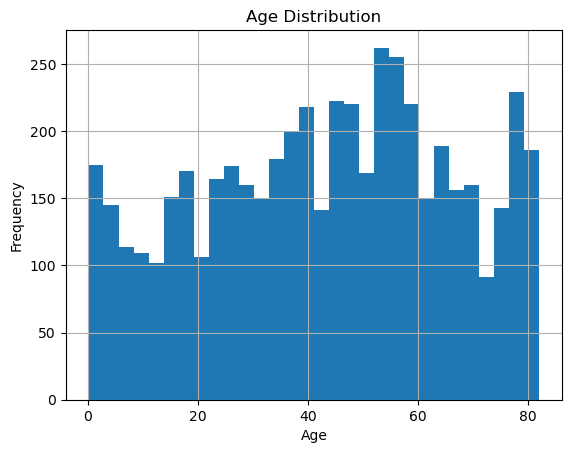

In [62]:
df['age'].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#### Most individuals fall in the adult to elderly age group, and stroke cases are more frequent among higher age groups.

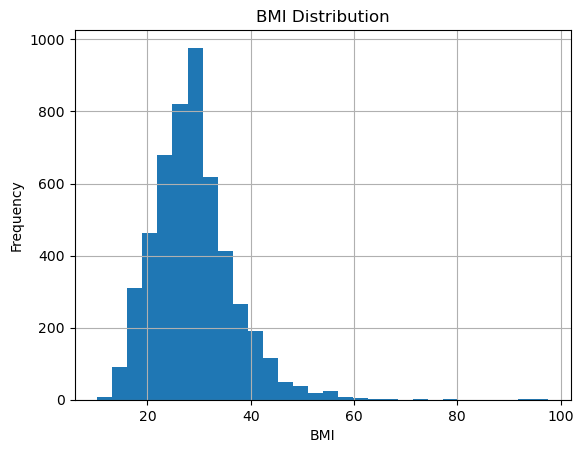

In [63]:
df['bmi'].hist(bins=30)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

#### BMI values are slightly right-skewed, showing some individuals with unusually high BMI values.

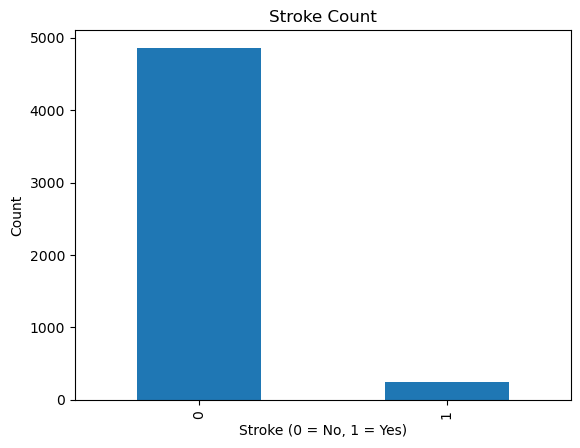

In [64]:
df['stroke'].value_counts().plot(kind='bar')
plt.title("Stroke Count")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

#### A very small proportion of individuals have experienced a stroke, confirming class imbalance.

## EDA — Bivariate Analysis

Relationship between hypertension, heart disease and stroke is analyzed.


In [65]:
pd.crosstab(df['hypertension'], df['stroke'])

stroke,0,1
hypertension,,
0,4429,183
1,432,66


#### Individuals with hypertension show a higher proportion of stroke cases compared to those without hypertension.

In [66]:
pd.crosstab(df['heart_disease'], df['stroke'])

stroke,0,1
heart_disease,,
0,4632,202
1,229,47


#### Patients with heart disease have a significantly higher likelihood of stroke.

## EDA — Multivariate Analysis

Multiple health factors like glucose level and stroke are analyzed together.


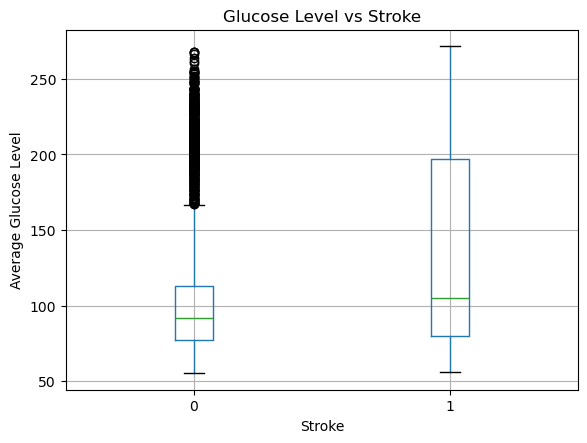

In [67]:
df.boxplot(column='avg_glucose_level', by='stroke')
plt.title("Glucose Level vs Stroke")
plt.suptitle("")
plt.xlabel("Stroke")
plt.ylabel("Average Glucose Level")
plt.show()

#### Stroke patients tend to have higher average glucose levels compared to non-stroke patients.

## Pivot Tables

Pivot tables are created to summarize stroke occurrence across categories.


In [68]:
pd.pivot_table(df, values='stroke', index='work_type', aggfunc='mean')

,stroke
work_type,
Govt_job,0.050228
Never_worked,0.000000
Private,0.050940
Self-employed,0.079365
children,0.002911


#### Certain work types show slightly higher stroke occurrence, possibly due to lifestyle or stress factors.

In [69]:
pd.pivot_table(df, values='stroke', index='smoking_status', aggfunc='mean')

,stroke
smoking_status,
Unknown,0.030440
formerly smoked,0.079096
never smoked,0.047569
smokes,0.053232


#### Smokers and formerly smokers show higher stroke rates than non-smokers.

## Key Insights

- Stroke cases are more common among elderly individuals.
- Hypertension and heart disease increase stroke risk.
- Higher glucose levels are observed in stroke patients.
- Smokers show relatively higher stroke occurrence.


## Conclusion

EDA revealed important health and lifestyle factors associated with stroke.
This dataset is suitable for further predictive modeling and healthcare analysis.
